# 02 Image Processing Fundamentals and Feature Extraction

## 📚 Learning Objectives

By completing this notebook, you will:
- See an image as an **array of pixels** and apply **normalization**
- Extract a classic hand-crafted feature — **edges** — with a small convolution (the operation CNNs learn automatically)
- Apply basic **data augmentation** (shift, flip, rotation, noise) and understand when each is safe
- As a complement: encode **categorical features** for a scikit-learn baseline classifier

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 08 "Feature Extraction from Unstructured Data" — features designed by hand; here we contrast them with the ones a CNN learns for itself.

---

## 🌍 Real life

**📌 Real case — a decade of face boxes, all hand-designed.** Viola and Jones (CVPR 2001) built the first face detector fast enough to run in real time, and every feature it used was designed by a human: rectangular light/dark contrasts (Haar-like features) fed into a cascade of simple classifiers. It was good enough that the little green box in consumer digital cameras ran on it for roughly a decade. Not one of its features was learned. The Sobel kernels you are about to slide across a digit are that world in nine numbers — and the `Conv2D` layer in notebook `01` has exactly the same shape, with the numbers filled in by training instead of by a person.

**⚡ Why this matters — what goes wrong without it.** Before 2012 a computer-vision project *was* feature design. Someone chose Sobel, or HOG, or SIFT, and if the choice was wrong the model on top could not recover — you went back and chose again. Understanding this notebook is what lets you read a CNN's first layer and recognise that it has rediscovered edge detectors on its own. And augmentation matters for the opposite reason: it is the cheapest way to get more training data, and the fastest way to inject wrong labels if you pick the wrong transform.

---

**📌 Covers slide(s):** **10** — Image Processing Basics (pixels, normalization, augmentation). *Do this notebook after that slide.* We demonstrate on sklearn's built-in 8×8 digits (no download); the identical operations apply to CIFAR-10, which notebook `07_training_cnn_image_datasets` trains on.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, scikit-learn (built-in digits dataset; a small synthetic table for the encoding demo). No downloads.

**Outputs:** Pixel values and a normalized image, edge maps from a hand-written convolution, a grid of augmented images, and accuracy / confusion matrix for the tabular baseline classifier.

---


## Step 1: An image is an array of pixels

A grayscale image is a 2D grid of numbers (one **channel**); a color image stacks three grids (**R, G, B channels**). Neural networks work on these numbers directly, and training is more stable when the values are **normalized** to a small range like [0, 1] — exactly what `x / 255.0` does for MNIST and CIFAR-10 in later notebooks (the digits below use a 0–16 scale, so we divide by 16).

Label: 0
Image shape: (8, 8) (8×8 grid, 1 grayscale channel)
Pixel value range: 0 to 15

The raw pixel numbers:
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]

After normalization: 0.00 to 0.94


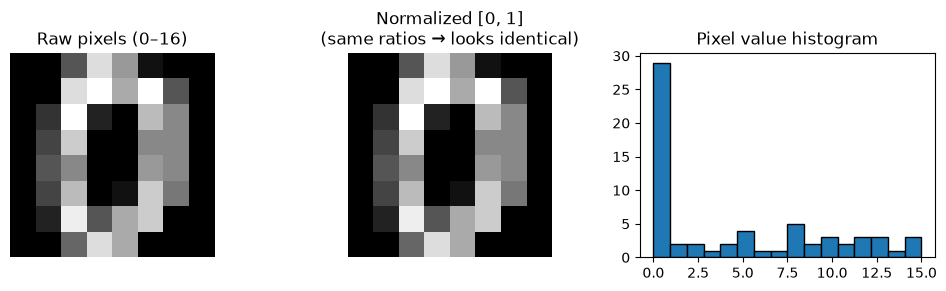

In [1]:
# WHAT: load one 8x8 digit image and inspect its raw pixel numbers, then normalize them to [0, 1].
# WHY: an image IS a grid of numbers - seeing the actual values demystifies what a CNN consumes.
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
img = digits.images[0]                       # first image, label:
print("Label:", digits.target[0])
print("Image shape:", img.shape, "(8×8 grid, 1 grayscale channel)")
print("Pixel value range: %.0f to %.0f" % (img.min(), img.max()))
print()
print("The raw pixel numbers:")
print(img.astype(int))

# Dividing by the max value (16) rescales to [0, 1]; the ratios between pixels are unchanged.
img_norm = img / 16.0                        # normalize to [0, 1]
print()
print("After normalization: %.2f to %.2f" % (img_norm.min(), img_norm.max()))

# Show raw vs normalized images (identical to the eye) plus the histogram of pixel values.
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Raw pixels (0–16)")
axes[1].imshow(img_norm, cmap="gray"); axes[1].set_title("Normalized [0, 1]\n(same ratios → looks identical)")
axes[2].hist(img.ravel(), bins=16, edgecolor="black"); axes[2].set_title("Pixel value histogram")
for ax in axes[:2]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Step 2: Feature extraction — edges via convolution

Before deep learning, practitioners **hand-designed** features such as edges. An edge detector is a small **kernel** (here the 3×3 Sobel filters) slid across the image — a **convolution**. This is exactly the operation a CNN's `Conv2D` layer performs, except the CNN **learns** its kernel values from data instead of us choosing them (see `01_cnn_architecture`).

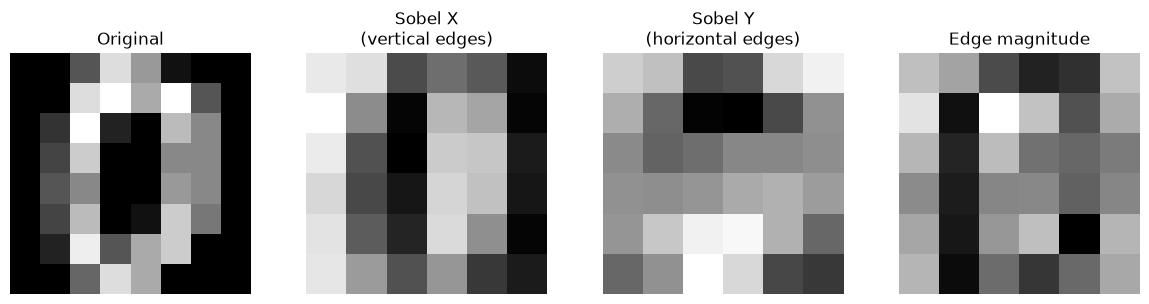

Hand-crafted feature extraction: a 3×3 kernel convolved over the image.
A CNN layer does the same operation but LEARNS its kernel values during training.


In [2]:
# WHAT: implement 2D convolution in pure NumPy and slide Sobel kernels over the digit.
# WHY: writing the sliding-window sum yourself removes all magic from Conv2D - same math, ten lines.
def convolve2d(image, kernel):
    """Minimal 2D convolution (no padding, stride 1) — same idea as Conv2D."""
    kh, kw = kernel.shape
    H, W = image.shape
    out = np.zeros((H - kh + 1, W - kw + 1))
    # Slide the kernel over every valid position; each output pixel is a weighted sum of its neighborhood.
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            out[r, c] = (image[r:r+kh, c:c+kw] * kernel).sum()
    return out

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)  # vertical edges
sobel_y = sobel_x.T                                                    # horizontal edges

# Apply both Sobel kernels, then combine the two directions into one edge-strength map.
gx = convolve2d(img_norm, sobel_x)
gy = convolve2d(img_norm, sobel_y)
edges = np.sqrt(gx**2 + gy**2)   # gradient magnitude

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, im, title in zip(axes, [img_norm, gx, gy, edges],
                         ["Original", "Sobel X\n(vertical edges)", "Sobel Y\n(horizontal edges)", "Edge magnitude"]):
    ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()
print("Hand-crafted feature extraction: a 3×3 kernel convolved over the image.")
print("A CNN layer does the same operation but LEARNS its kernel values during training.")

### The same convolution, one step at a time

The figure above shows the **finished** Sobel-X map. But the `for` loop that produced it visits one window at a time, and that is the part worth seeing. Below is a storyboard: six snapshots out of the 36 positions the 3×3 kernel visits.

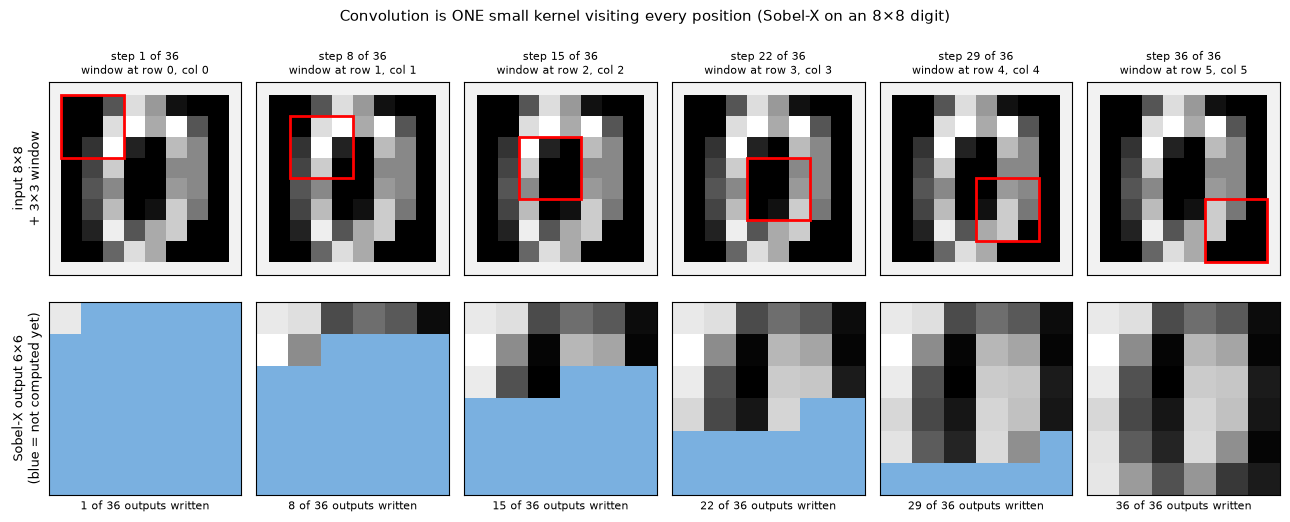

step | window (row, col) | value written to output
   1 | (0, 0)            | +2.875
   8 | (1, 1)            | +0.562
  15 | (2, 2)            | -2.938
  22 | (3, 3)            | +2.375
  29 | (4, 4)            | +0.625
  36 | (5, 5)            | -2.250

8×8 input, 3×3 kernel, stride 1, no padding  ->  (8-3+1) × (8-3+1) = 6×6 output, 36 positions.
The SAME nine numbers are reused at every one of those 36 positions - that reuse is the whole idea.


In [3]:
# WHAT: storyboard the sliding window - 6 snapshots out of the 36 positions the 3x3 kernel visits.
# WHY: the loop above computes one output pixel per window; watching it fill in is what "sliding" means.
import matplotlib.patches as mpatches

oh, ow = gx.shape                 # gx is the finished Sobel-X map from the cell above: 6 x 6
n_pos = oh * ow                   # 36 window positions for an 8x8 input and a 3x3 kernel
steps = [0, 7, 14, 21, 28, n_pos - 1]     # 6 cheap frames, evenly spread over the scan
vmin, vmax = gx.min(), gx.max()

# Same grey colormap as the finished Sobel-X panel above, so the last frame is literally that panel.
# Blue stands for "this output pixel has not been computed yet".
cmap_out = plt.get_cmap("gray").copy()
cmap_out.set_bad("#7ab0e0")

fig, axes = plt.subplots(2, len(steps), figsize=(13, 5.4))
for j, s in enumerate(steps):
    r, c = divmod(s, ow)                       # row-major scan order, exactly like the loop
    # Top: where the 3x3 window sits at this step.
    ax = axes[0, j]
    ax.imshow(img_norm, cmap="gray", interpolation="nearest")
    ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 3, 3, fill=False, edgecolor="red", lw=2.0))
    ax.set_xlim(-1.1, 8.1); ax.set_ylim(8.1, -1.1); ax.set_facecolor("#f2f2f2")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("step %d of %d\nwindow at row %d, col %d" % (s + 1, n_pos, r, c), fontsize=8)
    # Bottom: the output map with everything computed so far written in.
    ax = axes[1, j]
    partial = np.full(n_pos, np.nan)
    partial[:s + 1] = gx.ravel()[:s + 1]
    ax.imshow(partial.reshape(oh, ow), cmap=cmap_out, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("%d of %d outputs written" % (s + 1, n_pos), fontsize=8)
axes[0, 0].set_ylabel("input 8×8\n+ 3×3 window", fontsize=9)
axes[1, 0].set_ylabel("Sobel-X output 6×6\n(blue = not computed yet)", fontsize=9)
fig.suptitle("Convolution is ONE small kernel visiting every position (Sobel-X on an 8×8 digit)", fontsize=11)
plt.tight_layout(); plt.show()

# The step table: the exact number written at each snapshot, so the picture can be checked.
print("step | window (row, col) | value written to output")
for s in steps:
    r, c = divmod(s, ow)
    print("%4d | %-17s | %+.3f" % (s + 1, "(%d, %d)" % (r, c), gx[r, c]))
print("\n8×8 input, 3×3 kernel, stride 1, no padding  ->  (8-3+1) × (8-3+1) = 6×6 output, %d positions." % n_pos)
print("The SAME nine numbers are reused at every one of those %d positions - that reuse is the whole idea." % n_pos)

**Read the figure.** Top row: the red 3×3 window starts in the top-left corner and steps right, then down — six of its 36 stops are shown. Bottom row: the output map filling in behind it, grey where nothing has been computed yet; by the last frame all 36 cells are coloured and the map is **identical to the "Sobel X" panel in the figure above** — this is how that panel got filled in. Two things to notice: the window never hangs off the edge, which is exactly why an 8×8 input with a 3×3 kernel gives a 6×6 output; and the *same nine numbers* are reused at every stop. A `Conv2D` layer differs in one respect only — it learns those nine numbers instead of being handed them.

## Step 3: Data augmentation

**Augmentation** creates extra training images by transforming the ones we have — the model sees more variation and overfits less. Later notebooks rely on this idea (e.g. `07_training_cnn_image_datasets` asks you to add augmentation to a CIFAR-10 pipeline).

**Choose label-preserving transforms:** small shifts and light noise are safe almost everywhere; a horizontal flip is fine for cats vs dogs but **wrong for digits** (a mirrored “2” is not a digit), and a 90° rotation can turn a “6” into a “9” — we show them anyway so you can see the risk.

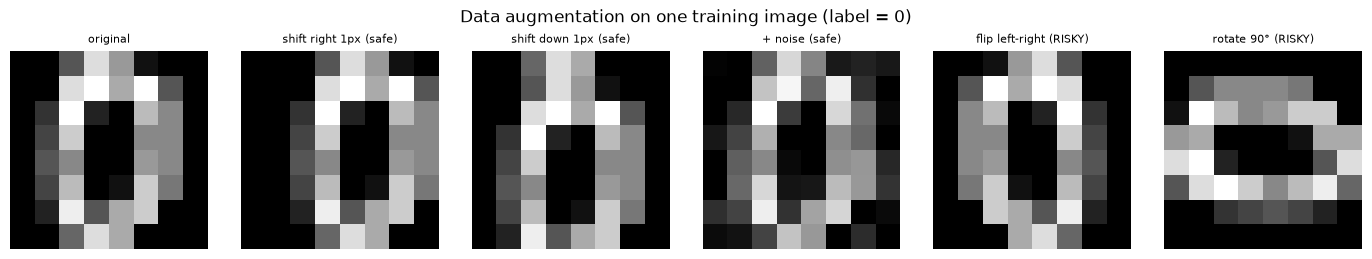

Safe transforms keep the label meaning; risky ones can change it —
for digits, use small shifts/noise, NOT flips or 90° rotations.


In [4]:
# WHAT: build augmented variants of one digit - shifts, noise, flips, rotations.
# WHY: augmentation multiplies training data for free, but only label-preserving transforms are safe.
rng = np.random.default_rng(0)

# np.roll shifts the image one pixel at a time without losing content.
def shift(image, dx, dy):
    return np.roll(np.roll(image, dy, axis=0), dx, axis=1)

# Safe transforms keep a digit readable as itself; flips and 90-degree turns can change its meaning.
augmented = {
    "original":                 img_norm,
    "shift right 1px (safe)":   shift(img_norm, 1, 0),
    "shift down 1px (safe)":    shift(img_norm, 0, 1),
    "+ noise (safe)":           np.clip(img_norm + rng.normal(0, 0.10, img_norm.shape), 0, 1),
    "flip left-right (RISKY)":  np.fliplr(img_norm),
    "rotate 90° (RISKY)":       np.rot90(img_norm),
}

# Plot every variant side by side so safe vs risky is visible.
fig, axes = plt.subplots(1, len(augmented), figsize=(14, 2.6))
for ax, (name, im) in zip(axes, augmented.items()):
    ax.imshow(im, cmap="gray"); ax.set_title(name, fontsize=8); ax.axis("off")
plt.suptitle("Data augmentation on one training image (label = %d)" % digits.target[0])
plt.tight_layout(); plt.show()

print("Safe transforms keep the label meaning; risky ones can change it —")
print("for digits, use small shifts/noise, NOT flips or 90° rotations.")

## Complement: encoding categorical features (tabular warm-up)

Not every input is an image. This short baseline shows the same **preprocess → model → evaluate** pipeline on a small synthetic table with a categorical `color` column, encoded with **OneHotEncoder**. The pipeline pattern is identical to what you will build for images with CNNs.

In [5]:
# Baseline classifier: synthetic data, OneHot for categorical, pipeline, evaluate
import numpy as np
import pandas as pd

# scikit-learn tools: train/test splitting, one-hot encoding for the categorical column, and a clean pipeline.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# small synthetic dataset
rng = np.random.default_rng(123)
n = 600
x1 = rng.normal(size=n)
x2 = rng.normal(size=n)
color = rng.choice(['red','green','blue'], size=n)

# The label depends on x1, x2 and color, plus noise - a learnable but not trivial rule.
y = ((x1 + 0.8*x2 + (color == 'red')*0.6 + rng.normal(scale=0.5, size=n)) > 0.2).astype(int)

df = pd.DataFrame({'x1': x1, 'x2': x2, 'color': color, 'y': y})
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ColumnTransformer one-hot-encodes 'color' and passes the numeric columns through unchanged.
pre = ColumnTransformer([
 ('cat', OneHotEncoder(handle_unknown='ignore'), ['color']),
], remainder='passthrough')

# Pipeline chains preprocessing + model so train and test preprocessing can never diverge.
clf = Pipeline([
 ('pre', pre),
 ('model', LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

# Evaluate on the held-out quarter: accuracy, confusion matrix, and a per-class report.
y_pred = clf.predict(X_test)
print('accuracy:', accuracy_score(y_test, y_pred))
print('confusion matrix:', confusion_matrix(y_test, y_pred))
print('\nreport:', classification_report(y_test, y_pred))

accuracy: 0.9266666666666666
confusion matrix: [[70  5]
 [ 6 69]]

report:               precision    recall  f1-score   support

           0       0.92      0.93      0.93        75
           1       0.93      0.92      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

Test accuracy on real handwritten digits: 96.9%


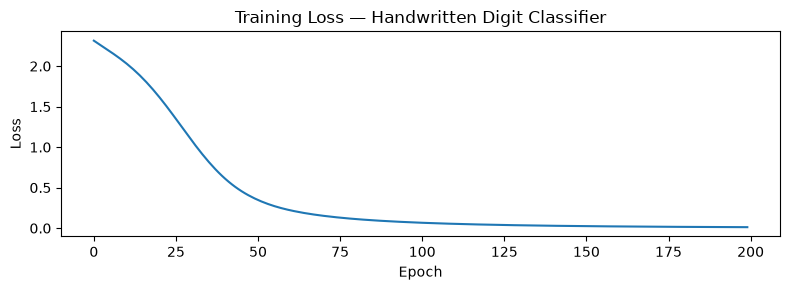

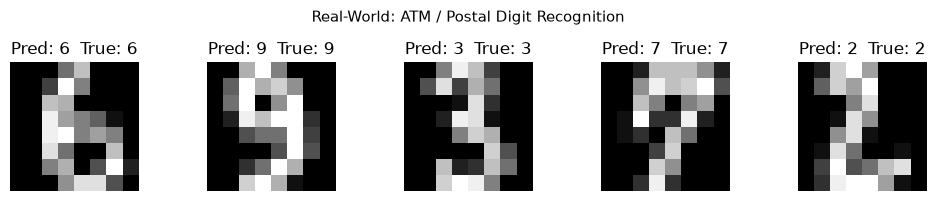

In [6]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

# Split FIRST (the 8×8 images travel with their rows), then scale with
# statistics from the training set only (no test-set leakage).
X_tr, X_te, y_tr, y_te, img_tr, img_te = train_test_split(
    X, y, digits.images, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr).astype(np.float32)
X_te = scaler.transform(X_te).astype(np.float32)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ──────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show sample predictions: test images paired with their own labels ─────
with torch.no_grad():
    sample_preds = model(X_te_t[:5]).argmax(1).tolist()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(img_te[i], cmap='gray')   # the SAME test image the model predicted on
    ax.set_title(f"Pred: {sample_preds[i]}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

## 💬 Discuss

1. We chose the Sobel numbers ourselves; a `Conv2D` layer learns its own. With only **200** labelled images, which would you bet on — and does your answer change at 200,000?
2. This notebook labels a flip and a 90° rotation as "risky" for digits. Pick a dataset you have actually seen and name a transform that looks obviously safe but is not. Convince the person next to you.
3. Your client's product photos were all taken in one warehouse under one set of lights. Augmentation can give you ten times more images. Can it give you a model that works in a second warehouse? Say precisely what it can and cannot do here.


## ⚠️ Where this breaks

- **Hand-crafted edges are brittle in a way the notebook can show you.** The Sobel response scales with contrast: the same stroke gives a strong edge on a bright scan and a weak one on a dark scan, and the kernel has no way to know they are the same thing. Normalisation helps and does not fix it.
- **Augmentation has a hard boundary, and this notebook draws it.** A horizontal flip is free training data for cats vs dogs and a **label error** for digits — a mirrored "2" is not a 2, and a 180° rotation turns a 6 into a 9. Every augmented image that breaks the label is a wrong label you paid compute to manufacture.
- **The rule is domain-specific, not universal.** Flipping a chest X-ray horizontally puts the heart on the wrong side of the image and quietly teaches the model that side does not matter. Flipping a photo of a road sign is fine in Saudi Arabia and fine in the UK; flipping a photo of *text* is never fine.
- **Augmentation makes the training set bigger, not more diverse.** Every generated image descends from one you already had. It cannot introduce a lighting condition, a camera or a demographic that your original data lacked — which is precisely the gap that hurts you in deployment.
- **The assumption that must hold:** your chosen transform preserves the label *for your task*. Write the transform list down and have a domain expert sign it. This is a five-minute conversation that prevents a month of confusion.
- **Cheaper alternative:** if you only need edges, `cv2.Sobel` runs in microseconds and needs zero training data. Do not train a CNN to find edges.

**🔁 The same reasoning appears in:** audio (a spectrogram is a hand-designed feature that learned front-ends now sometimes replace), NLP (stemming and stop-word lists were hand-designed features before subword tokenisers learned theirs), and time-series (rolling means and lags are hand-designed features; Course 12's models learn them).


## Summary

- An image is an **array of pixels** (grayscale = 1 channel, RGB = 3); we **normalized** values to [0, 1].
- We extracted **edges** with a hand-written 3×3 convolution — the operation CNN layers learn automatically.
- We applied **data augmentation** (shifts, noise, flips, rotation) and saw which transforms are label-preserving for digits.
- As a complement, we built a **baseline classifier** with scikit-learn using **OneHotEncoder** for a categorical feature and evaluated it with accuracy, a confusion matrix, and a classification report.
- The pipeline pattern (preprocess → model → evaluate) is the same one you will use with image data and CNNs in the rest of this unit.


## 📚 References

1. LeCun, Y., Bottou, L., Bengio, Y. & Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition*. Proceedings of the IEEE 86(11), 2278-2324.
2. Krizhevsky, A., Sutskever, I. & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS. https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html
3. Cubuk, E. D., Zoph, B., Shlens, J. & Le, Q. V. (2020). *RandAugment: Practical Automated Data Augmentation with a Reduced Search Space*. NeurIPS. https://arxiv.org/abs/1909.13719

**Recent work (2024–2026)**

4. Siméoni, O. et al. (2025). *DINOv3*. arXiv. https://arxiv.org/abs/2508.10104 — where hand-designed feature extraction went: a pretrained self-supervised backbone now supplies the features that filters and descriptors used to.
5. Nassar et al. (2025). *SmolDocling: An ultra-compact vision-language model for end-to-end multi-modal document conversion*. arXiv. https://arxiv.org/abs/2503.11576 — for document images specifically, the whole preprocessing pipeline is replaced by one small vision-language model that outputs structure directly.
